# Week 6 — Environmental Anomaly Detection + Time Series
## EDA — Nairobi Air Quality Data (OpenAQ)

**Business Problem:** Air quality sensors in Nairobi generate hourly readings. 
This pipeline forecasts future pollution levels and flags dangerous anomalies automatically.

**Dataset:** OpenAQ — 11,998 real sensor readings from 5 Nairobi locations

**Goal:** Understand the data before building ARIMA, Prophet, LSTM and Isolation Forest models

**Author:** Martin James Ng'ang'a | github.com/M20Jay

## Section 1: Import Libraries:

In [33]:
# Section 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,5)

print("Libraries loaded successfully ✅")
print(f"Pandas : {pd.__version__}")
print(f"Numpy : {np.__version__}")

Libraries loaded successfully ✅
Pandas : 2.2.2
Numpy : 1.26.4


## Section 2 — Load Dataset

In [34]:
# Load raw data
df = pd.read_csv('../data/raw/nairobi_aqi_20260506.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (11998, 26)

Columns:
['value', 'coordinates', 'summary', 'flagInfo.hasFlags', 'parameter.id', 'parameter.name', 'parameter.units', 'parameter.displayName', 'period.label', 'period.interval', 'period.datetimeFrom.utc', 'period.datetimeFrom.local', 'period.datetimeTo.utc', 'period.datetimeTo.local', 'coverage.expectedCount', 'coverage.expectedInterval', 'coverage.observedCount', 'coverage.observedInterval', 'coverage.percentComplete', 'coverage.percentCoverage', 'coverage.datetimeFrom.utc', 'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc', 'coverage.datetimeTo.local', 'sensor_id', 'location_name']

Data types:
value                          float64
coordinates                    float64
summary                        float64
flagInfo.hasFlags                 bool
parameter.id                     int64
parameter.name                  object
parameter.units                 object
parameter.displayName          float64
period.label                    object
period.interval  

## Section 3 — First Look at the Data

In [35]:
# What parameters were measured?
print("Parameters measured:")
print(df['parameter.name'].value_counts())

print(f"\nLocations:")
print(df['location_name'].value_counts())

print(f"\nDate range:")
print(f"From : {df['coverage.datetimeFrom.utc'].min()}")
print(f"To:   {df['period.datetimeFrom.utc'].max()}")

print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Parameters measured:
parameter.name
pm25                3347
temperature         3000
pm10                2300
pm1                 1789
relativehumidity     781
um003                781
Name: count, dtype: int64

Locations:
location_name
Nyayo Embakasi, Nairobi    5140
Nairobi                    5000
Nairobi CBD                1022
Alliance Girls High         836
Name: count, dtype: int64

Date range:
From : 2018-04-20T23:00:00Z
To:   2024-05-09T17:00:00Z

Missing values:
coordinates              11998
summary                  11998
parameter.displayName    11998
dtype: int64


## Section 4 — Filter PM2.5 and Explore

In [36]:
# Filter to PM2.5 only — our primary target
df_pm25 = df[df['parameter.name'] == 'pm25'].copy()

print(f"PM2.5 rows: {len(df_pm25)}")
print(f"\nPM2.5 value statistics:")
print(df_pm25['value'].describe())

PM2.5 rows: 3347

PM2.5 value statistics:
count    3347.000000
mean       12.321200
std        15.873117
min         0.000000
25%         6.000000
50%         9.630000
75%        14.679881
max       469.230354
Name: value, dtype: float64


## Section 5 — Time Series Plot

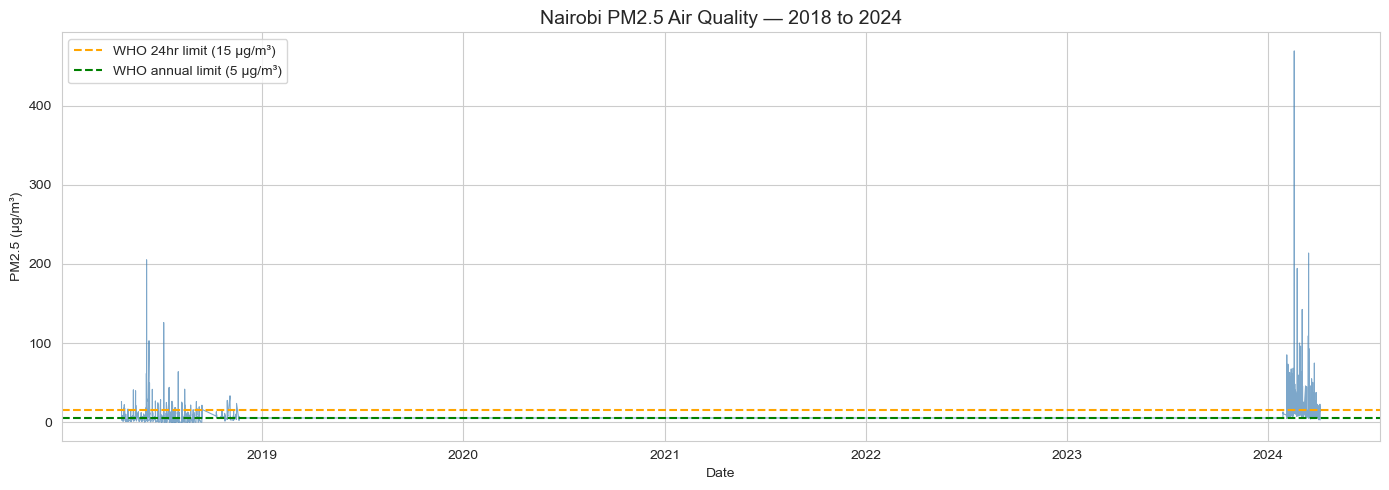

In [39]:
# Convert timestamp to datetime
df_pm25['datetime'] = pd.to_datetime(df_pm25['period.datetimeFrom.utc'])
df_pm25 = df_pm25.sort_values('datetime')

# Plot PM2.5 over time
plt.figure(figsize=(14,5))
plt.plot(df_pm25['datetime'], df_pm25['value'], color='steelblue', linewidth=0.8, alpha=0.7)
plt.axhline(y=15, color='orange', linestyle='--', label='WHO 24hr limit (15 µg/m³)')
plt.axhline(y=5, color='green', linestyle='--', label='WHO annual limit (5 µg/m³)')
plt.title('Nairobi PM2.5 Air Quality — 2018 to 2024', fontsize=14)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/pm25_nairobi_2018_2024.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Focus on 2024 Data

The time series chart reveals a significant data gap from 2019 to mid-2023.
ARIMA, Prophet and LSTM all require continuous time series data.
A 4-year gap violates this assumption and would produce unreliable forecasts.

**Decision:** Focus on 2024 data only.

**Rationale:**
- Most complete and continuous readings
- Most recent — most relevant for current air quality forecasting
- Contains the highest pollution spikes — ideal for anomaly detection training
- Sufficient volume for time series modelling

In [ ]:
# Filter to 2024 — most complete and continuous data
df_2024 = df_pm25[df_pm25['datetime'].dt.year == 2024].copy()

print(f"2024 rows: {len(df_2024)}")
print(f"Date range: {df_2024['datetime'].min()} to {df_2024['datetime'].max()}")
print(f"\nLocations in 2024:")
print(df_2024.groupby('location_name')['value'].count())
print(f"\nValue statistics:")
print(df_2024['value'].describe())

2024 rows: 2000
Date range: 2024-01-28 14:55:32+00:00 to 2024-04-05 01:00:00+00:00

Locations in 2024:
location_name
Nairobi                    1000
Nyayo Embakasi, Nairobi    1000
Name: value, dtype: int64

Value statistics:
count    2000.000000
mean       15.872279
std        17.704807
min         2.714435
25%         8.800000
50%        11.860000
75%        17.973237
max       469.230354
Name: value, dtype: float64


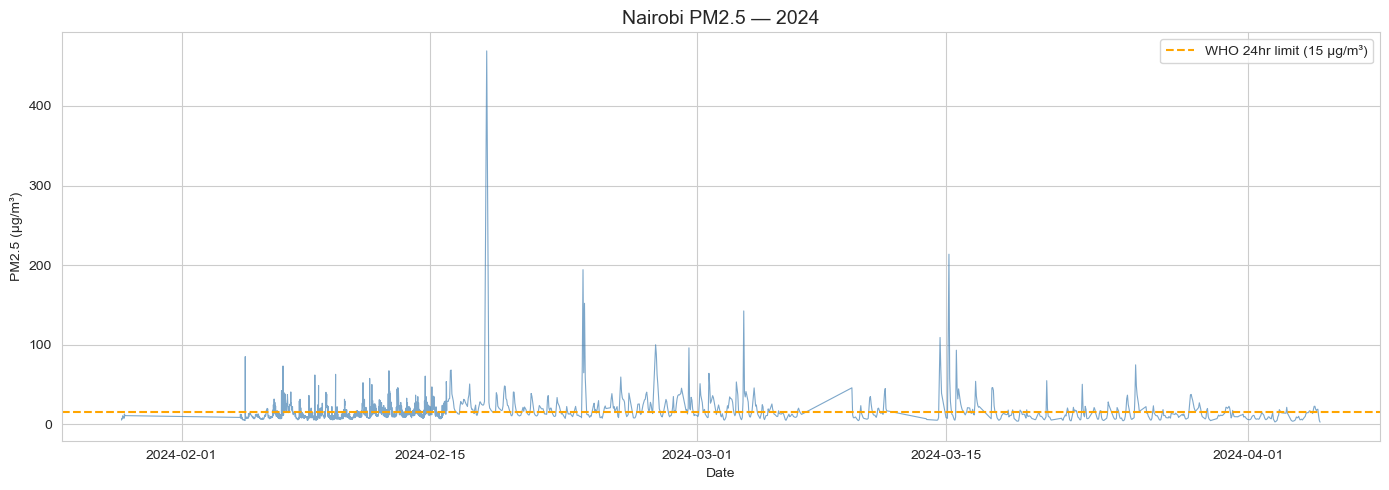

In [41]:
# PM2.5 time series — 2024
plt.figure(figsize=(14, 5))
plt.plot(df_2024.index, df_2024['value'],
         color='steelblue', linewidth=0.8, alpha=0.7)
plt.axhline(y=15, color='orange', linestyle='--',
            label='WHO 24hr limit (15 µg/m³)')
plt.title('Nairobi PM2.5 — 2024', fontsize=14)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/pm25_nairobi_2024.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Resample to Hourly Frequency

In [ ]:
# datetime is already the index
# Resample to hourly frequency — mean of each hour
df_hourly = df_2024['value'].resample('h').mean()

print(f"Hourly series shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")
print(f"Missing hours: {df_hourly.isnull().sum()}")
print(f"\nFirst 5 rows:")
print(df_hourly.head())

Hourly series shape: (1620,)
Date range: 2024-01-28 14:00:00+00:00 to 2024-04-05 01:00:00+00:00
Missing hours: 498

First 5 rows:
datetime
2024-01-28 14:00:00+00:00    5.320000
2024-01-28 15:00:00+00:00    6.766667
2024-01-28 16:00:00+00:00    9.137500
2024-01-28 17:00:00+00:00    8.816667
2024-01-28 18:00:00+00:00    9.267500
Freq: h, Name: value, dtype: float64


In [ ]:
# Fill missing hours using linear interpolation
df_hourly_filled = df_hourly.interpolate(method='linear')

print(f"Missing after fill: {df_hourly_filled.isnull().sum()}")
print(f"\nValue statistics after fill:")
print(df_hourly_filled.describe())

Missing after fill: 0

Value statistics after fill:
count    1620.000000
mean       17.506203
std        21.461559
min         2.714435
25%         9.794048
50%        12.533147
75%        19.602790
max       469.230354
Name: value, dtype: float64


## Section 8 — Distribution Analysis

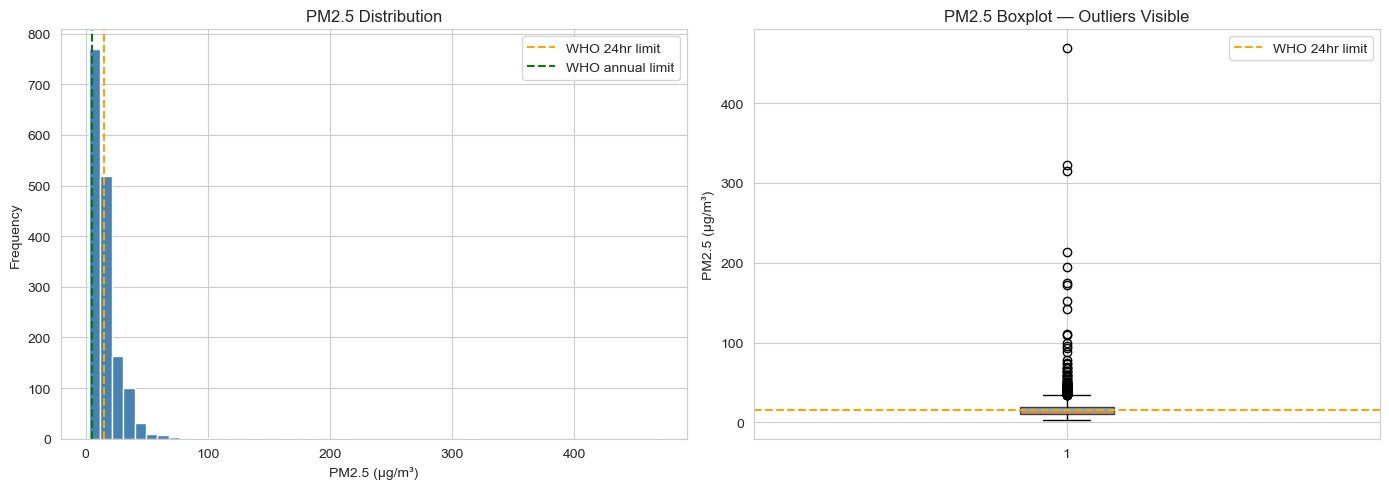

Skewness: 11.131870
Kurtosis: 180.363


In [42]:
fig,axes = plt.subplots(1,2, figsize=(14,5))

# Histogram
axes[0].hist(df_hourly_filled, bins=50,color='steelblue', edgecolor='white' )
axes[0].axvline(x=15, color='orange', linestyle='--', label='WHO 24hr limit')
axes[0].axvline(x=5, color='green', linestyle='--', label='WHO annual limit')
axes[0].set_title("PM2.5 Distribution")
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

#Boxplot
axes[1].boxplot(df_hourly_filled.dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue',alpha=0.7))
axes[1].axhline(y=15, color='orange', linestyle='--',label='WHO 24hr limit')
axes[1].set_title('PM2.5 Boxplot — Outliers Visible')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()

plt.tight_layout()
# Section 8 — distribution
plt.savefig('../screenshots/pm25_distribution_boxplot.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness: {df_hourly_filled.skew():3f}")
print(f"Kurtosis: {df_hourly_filled.kurtosis():.3f}")


## Section 9 — Stationarity Test (ADF Test)

In [43]:
from statsmodels.tsa.stattools import adfuller
result =adfuller(df_hourly_filled.dropna())

print(f" ADF Statistic:{result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"    {key} : {value:.4f}")

if result[1] < 0.05:
    print("\n✅ Series is STATIONARY (p < 0.05)")
    print("ARIMA d parameter = 0")
else:
    print("\n⚠️ Series is NON-STATIONARY (p >= 0.05)")
    print("ARIMA d parameter = 1 (differencing needed)")

 ADF Statistic:-9.2467
p-value: 0.0000
Critical Values:
    1% : -3.4344
    5% : -2.8633
    10% : -2.5677

✅ Series is STATIONARY (p < 0.05)
ARIMA d parameter = 0


## Section 10 — Seasonal Patterns

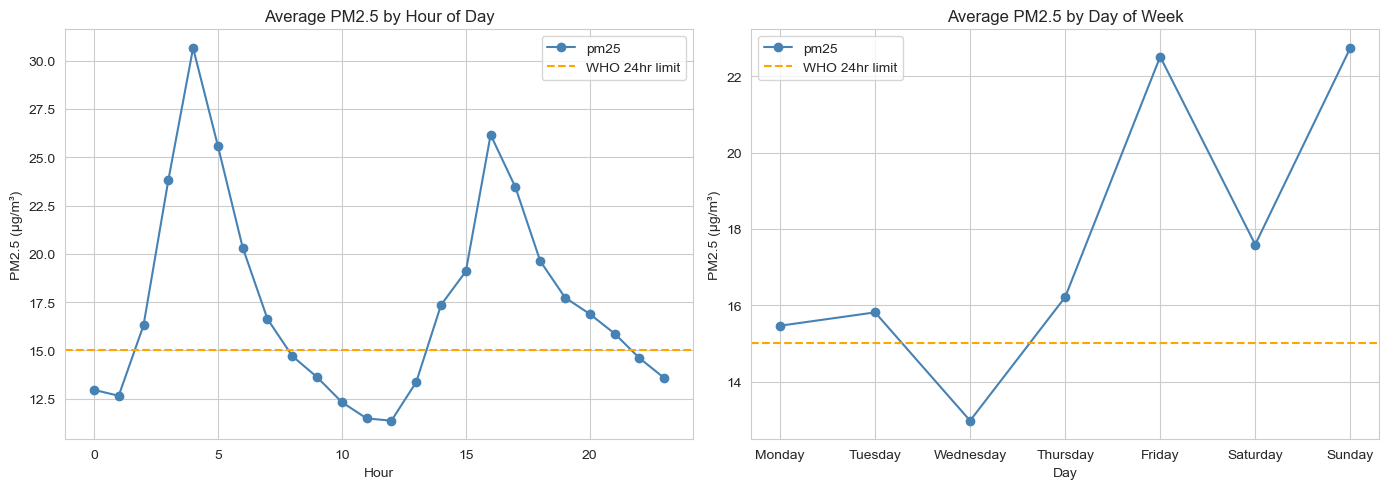

In [47]:
## Section 10 — Seasonal Patterns
df_seasonal = df_hourly_filled.copy()
df_seasonal = df_seasonal.to_frame(name='pm25')
df_seasonal['hour'] = df_seasonal.index.hour
df_seasonal['dayofweek']= df_seasonal.index.dayofweek
df_seasonal['day_name']=df_seasonal.index.day_name()

# Hourly pattern
fig, axes = plt.subplots(1,2, figsize=(14,5))

df_seasonal.groupby('hour')['pm25'].mean().plot(
    ax=axes[0], color='steelblue', marker='o')
axes[0].axhline(y=15, color ='orange', linestyle='--', label='WHO 24hr limit')
axes[0].set_title('Average PM2.5 by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()

# Daily pattern
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

df_seasonal.groupby('day_name')['pm25'].mean().reindex(day_order).plot(ax=axes[1], color='steelblue', marker ='o')
axes[1].axhline(y=15, color='orange', linestyle='--', label='WHO 24hr limit')
axes[1].set_title('Average PM2.5 by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../screenshots/pm25_seasonal_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — Anomaly Preview

Before building the Isolation Forest model, this section manually identifies
dangerous readings using established air quality thresholds.

The US EPA threshold of 55.4 µg/m³ marks "Unhealthy for All Groups" —
above this level, air quality affects everyone, not just sensitive groups.

This preview validates the contamination parameter in configs/model.yaml
before model training.

In [49]:
# Flag readings above dangerous threshold
threshold_high = 55.4    # Unhealthy for all groups
threshold_very_high = 150.4  # Very unhealthy

anomalies = df_hourly_filled[df_hourly_filled > threshold_high]

print(f" Readings above {threshold_high} µg/m³: {len(anomalies)}")
print(f"Percentage: {len(anomalies)/len(df_hourly_filled)*100:.1f}")
print(f"\nTop 10 worst readings:")
print(df_hourly_filled.nlargest(10))

 Readings above 55.4 µg/m³: 29
Percentage: 1.8

Top 10 worst readings:
datetime
2024-02-18 04:00:00+00:00    469.230354
2024-02-18 05:00:00+00:00    321.939829
2024-02-18 03:00:00+00:00    315.585118
2024-03-15 04:00:00+00:00    213.753274
2024-02-23 14:00:00+00:00    194.316518
2024-02-18 06:00:00+00:00    174.649304
2024-02-18 02:00:00+00:00    172.135342
2024-02-23 16:00:00+00:00    152.076191
2024-03-03 15:00:00+00:00    142.470386
2024-03-15 03:00:00+00:00    110.644197
Name: value, dtype: float64


## Section 12 — Save Processed Data

In [51]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save hourly filled series
df_hourly_filled.to_csv('../data/processed/nairobi_pm25_hourly.csv')

# Save seasonal dataframe
df_seasonal.to_csv('../data/processed/nairobi_pm25_seasonal.csv')

print("Saved:")
print("→ data/processed/nairobi_pm25_hourly.csv")
print("→ data/processed/nairobi_pm25_seasonal.csv")
print(f"\nHourly shape: {df_hourly_filled.shape}")
print(f"Seasonal shape: {df_seasonal.shape}")


Saved:
→ data/processed/nairobi_pm25_hourly.csv
→ data/processed/nairobi_pm25_seasonal.csv

Hourly shape: (1620,)
Seasonal shape: (1620, 4)
